Loading landmark data...
Loaded 256 landmark frames
Loading clip ranges...
Loaded 10 clip segments
Processing landmarks by clips...
Calculated motion data for 1217 frames
Acceleration range: -14801.25 to 7410.82
Velocity range: 0.11 to 247.49
Creating motion analysis plots...


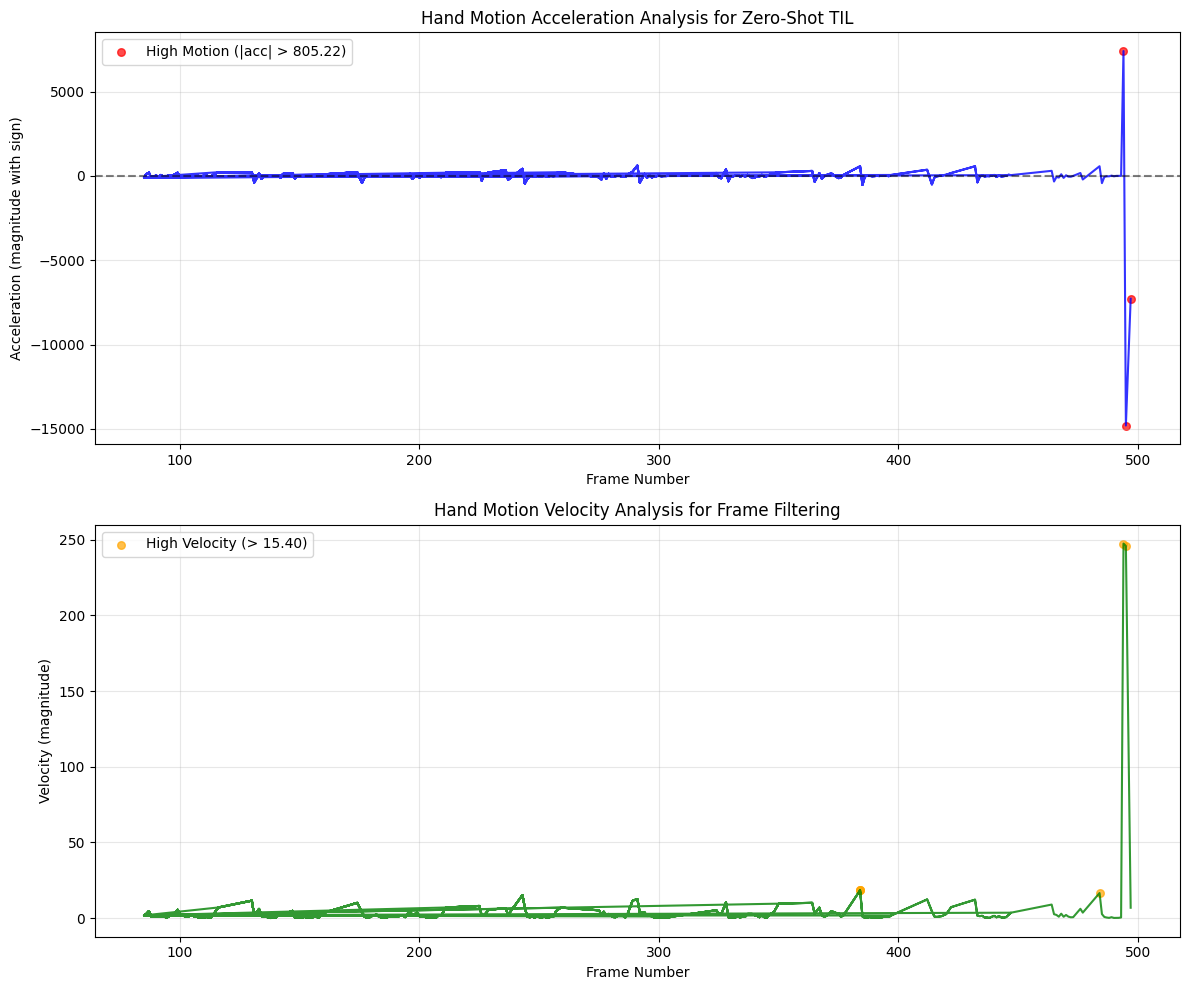


=== Frame Filtering Insights for Zero-Shot TIL ===
High-motion frames identified: 7 out of 1217
Motion filtering ratio: 0.6%


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_landmarks_file(filename):
    """
    Parse the landmarks file and extract frame numbers and coordinates.
    
    Returns:
        dict: Dictionary with frame numbers as keys and coordinate dictionaries as values
    """
    landmarks_data = {}
    
    with open(filename, 'r') as file:
        content = file.read()
        
    # Split by frame markers
    frame_blocks = re.split(r'(\d+):', content)
    
    for i in range(1, len(frame_blocks), 2):
        frame_num = int(frame_blocks[i])
        landmark_block = frame_blocks[i + 1]
        
        # Extract x, y, z coordinates
        x_match = re.search(r'x:\s*([-+]?\d*\.?\d+)', landmark_block)
        y_match = re.search(r'y:\s*([-+]?\d*\.?\d+)', landmark_block)
        z_match = re.search(r'z:\s*([-+]?\d*\.?\d+)', landmark_block)
        
        if x_match and y_match and z_match:
            landmarks_data[frame_num] = {
                'x': float(x_match.group(1)),
                'y': float(y_match.group(1)),
                'z': float(z_match.group(1))
            }
    
    return landmarks_data

def parse_clip_ranges(filename):
    """
    Parse clip ranges file to get segment boundaries.
    
    Returns:
        list: List of tuples containing (start_frame, end_frame)
    """
    clip_ranges = []
    
    with open(filename, 'r') as file:
        lines = file.readlines()
        
    for line in lines:
        # Extract numbers from each line
        numbers = re.findall(r'\d+', line.strip())
        if len(numbers) >= 2:
            start_frame = int(numbers[0])
            end_frame = int(numbers[1])
            clip_ranges.append((start_frame, end_frame))
    
    return clip_ranges

def calculate_hand_acceleration_magnitude(landmarks, fps=30):
    """
    Calculate acceleration magnitude for 3D hand landmark positions.
    
    Args:
        landmarks: List of dictionaries with 'x', 'y', 'z' keys for each frame
        fps: Frame rate (default 30 fps for EgoPAT-3D)
    
    Returns:
        acceleration_magnitudes: List of signed acceleration magnitudes
                               (+ve = acceleration, -ve = deceleration/retardation)
        velocity_magnitudes: List of velocity magnitudes (unsigned)
    """
    if len(landmarks) < 3:
        return [], []
    
    # Convert to numpy array for vectorized operations
    positions = np.array([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    
    # Calculate time step
    dt = 1.0 / fps
    
    # First derivative: velocity = dp/dt
    velocities = np.diff(positions, axis=0) / dt
    
    # Calculate velocity magnitudes (unsigned)
    velocity_magnitudes = np.linalg.norm(velocities, axis=1)
    
    # Second derivative: acceleration = dv/dt
    accelerations = np.diff(velocities, axis=0) / dt
    
    # Calculate acceleration magnitudes
    accel_magnitudes = np.linalg.norm(accelerations, axis=1)
    
    # Determine sign: positive for acceleration, negative for retardation
    # Compare speed changes between consecutive frames
    speed_prev = np.linalg.norm(velocities[:-1], axis=1)
    speed_curr = np.linalg.norm(velocities[1:], axis=1)
    speed_change = speed_curr - speed_prev
    
    # Apply sign based on speed change
    signed_acceleration = accel_magnitudes * np.sign(speed_change)
    
    return signed_acceleration.tolist(), velocity_magnitudes.tolist()

def process_landmarks_by_clips(landmarks_data, clip_ranges, fps=30):
    """
    Process landmarks by clips, calculating velocity and acceleration for each segment.
    
    Returns:
        tuple: (all_frame_numbers, all_velocities, all_accelerations)
    """
    all_frame_numbers = []
    all_velocities = []
    all_accelerations = []
    
    for start_frame, end_frame in clip_ranges:
        # Get landmarks for this clip
        clip_frames = []
        clip_landmarks = []
        
        for frame_num in sorted(landmarks_data.keys()):
            if start_frame <= frame_num <= end_frame:
                clip_frames.append(frame_num)
                clip_landmarks.append(landmarks_data[frame_num])
        
        if len(clip_landmarks) >= 3:
            # Calculate acceleration and velocity for this clip
            accelerations, velocities = calculate_hand_acceleration_magnitude(clip_landmarks, fps)
            
            # Acceleration starts from frame 2 (index 2) in the clip
            accel_frames = clip_frames[2:]  # Skip first 2 frames for acceleration
            vel_frames = clip_frames[1:]    # Skip first frame for velocity
            
            # Store results
            all_frame_numbers.extend(accel_frames)
            all_accelerations.extend(accelerations)
            
            # For velocity, we need to align with acceleration frames
            # Take velocity values that correspond to acceleration frames
            aligned_velocities = velocities[1:]  # Skip first velocity to align with acceleration
            all_velocities.extend(aligned_velocities)
    
    return all_frame_numbers, all_velocities, all_accelerations

def create_motion_analysis_plots(frame_numbers, velocities, accelerations):
    """
    Create two plots: acceleration (with sign) and velocity (magnitude only) vs frame numbers.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Acceleration (magnitude with sign)
    ax1.plot(frame_numbers, accelerations, 'b-', linewidth=1.5, alpha=0.8)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Acceleration (magnitude with sign)')
    ax1.set_title('Hand Motion Acceleration Analysis for Zero-Shot TIL')
    ax1.grid(True, alpha=0.3)
    
    # Highlight high acceleration regions
    high_accel_threshold = np.std(accelerations) * 1.5
    high_accel_indices = [i for i, acc in enumerate(accelerations) if abs(acc) > high_accel_threshold]
    if high_accel_indices:
        high_accel_frames = [frame_numbers[i] for i in high_accel_indices]
        high_accel_values = [accelerations[i] for i in high_accel_indices]
        ax1.scatter(high_accel_frames, high_accel_values, c='red', s=30, alpha=0.7, 
                   label=f'High Motion (|acc| > {high_accel_threshold:.2f})')
        ax1.legend()
    
    # Plot 2: Velocity (magnitude only)  
    ax2.plot(frame_numbers, velocities, 'g-', linewidth=1.5, alpha=0.8)
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Velocity (magnitude)')
    ax2.set_title('Hand Motion Velocity Analysis for Frame Filtering')
    ax2.grid(True, alpha=0.3)
    
    # Highlight high velocity regions
    high_vel_threshold = np.std(velocities) * 1.5
    high_vel_indices = [i for i, vel in enumerate(velocities) if vel > high_vel_threshold]
    if high_vel_indices:
        high_vel_frames = [frame_numbers[i] for i in high_vel_indices]
        high_vel_values = [velocities[i] for i in high_vel_indices]
        ax2.scatter(high_vel_frames, high_vel_values, c='orange', s=30, alpha=0.7,
                   label=f'High Velocity (> {high_vel_threshold:.2f})')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def main():
    """
    Main function to execute the complete analysis pipeline.
    """
    # File paths
    landmarks_file = "../test_data/5th_landmarks_trimmed.txt"
    clip_ranges_file = "../test_data/clip_ranges_10.txt"
    
    print("Loading landmark data...")
    landmarks_data = parse_landmarks_file(landmarks_file)
    print(f"Loaded {len(landmarks_data)} landmark frames")
    
    print("Loading clip ranges...")
    clip_ranges = parse_clip_ranges(clip_ranges_file)
    print(f"Loaded {len(clip_ranges)} clip segments")
    
    print("Processing landmarks by clips...")
    frame_numbers, velocities, accelerations = process_landmarks_by_clips(
        landmarks_data, clip_ranges, fps=30
    )
    
    print(f"Calculated motion data for {len(frame_numbers)} frames")
    print(f"Acceleration range: {min(accelerations):.2f} to {max(accelerations):.2f}")
    print(f"Velocity range: {min(velocities):.2f} to {max(velocities):.2f}")
    
    # Create analysis plots
    print("Creating motion analysis plots...")
    fig = create_motion_analysis_plots(frame_numbers, velocities, accelerations)
    
    # Generate frame filtering insights for zero-shot TIL
    print("\n=== Frame Filtering Insights for Zero-Shot TIL ===")
    
    # High motion frame detection
    accel_threshold = np.std(accelerations) * 1.5
    vel_threshold = np.std(velocities) * 1.5
    
    high_motion_frames = []
    for i, (frame, acc, vel) in enumerate(zip(frame_numbers, accelerations, velocities)):
        if abs(acc) > accel_threshold or vel > vel_threshold:
            high_motion_frames.append(frame)
    
    print(f"High-motion frames identified: {len(high_motion_frames)} out of {len(frame_numbers)}")
    print(f"Motion filtering ratio: {len(high_motion_frames)/len(frame_numbers)*100:.1f}%")
    
    # Return results for further analysis
    return {
        'frame_numbers': frame_numbers,
        'velocities': velocities,
        'accelerations': accelerations,
        'high_motion_frames': high_motion_frames,
        'landmarks_data': landmarks_data,
        'clip_ranges': clip_ranges
    }

if __name__ == "__main__":
    results = main()
